In [1]:
import sys
from os.path import dirname

sys.path.append("../src/")

In [2]:
from collections import Counter, defaultdict
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysam
import scipy as spy
import seaborn as sns
import sklearn as sk
import torch
from ExoModel.exo_model import ExoModel
from NucDPosITv2.em_nuc_model import CoordinateProbs, EMTorch
from NucDPosITv2.nuc_template_constants import ExoNucTemplate
from scipy.stats import gaussian_kde
from torch.utils.data import DataLoader, Dataset

In [3]:
BAM_PATH = "../data/reads/S_cerevisiae/SRR1802184/SRR1802184.sorted_bam"
BAM_FILE = pysam.AlignmentFile(BAM_PATH)

In [4]:
def calculate_template_length_distribution(bam_file, log_iter=1000000):
    # Открываем BAM файл
    bam = pysam.AlignmentFile(bam_file, "rb")

    # Словарь для хранения распределения длин
    length_dist = Counter()
    total_pairs = 0

    # Проходим по всем выравниваниям
    for read in bam:
        # Проверяем, что read является парным и правильно выровненным
        if read.is_paired and read.is_proper_pair and read.template_length > 0:
            # Берем абсолютное значение длины шаблона
            tl = read.template_length
            length_dist[tl] += 1
            total_pairs += 1
            if total_pairs % log_iter == 0:
                print(f"processed {total_pairs} reads")

    bam.close()
    return length_dist, total_pairs

In [5]:
tlens, all_counts = calculate_template_length_distribution(
    "../data/reads/S_cerevisiae/SRR1802184/SRR1802184.sorted_bam"
)

processed 1000000 reads
processed 2000000 reads
processed 3000000 reads
processed 4000000 reads
processed 5000000 reads


In [6]:
hist = [tlens[i] / all_counts for i in range(0, 199)]

In [7]:
max(tlens, key=tlens.get)

146

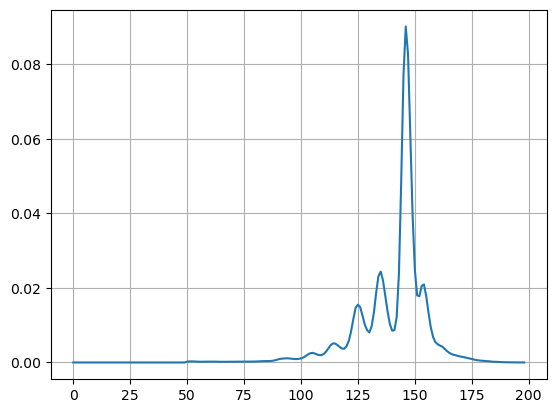

In [8]:
plt.plot(np.arange(len(hist)), hist)
plt.grid()

In [9]:
exo_model = ExoModel(146, 0.1)

In [10]:
exo_model.fit(hist)

ExoModel(l0=146, reg_koef=0.1)

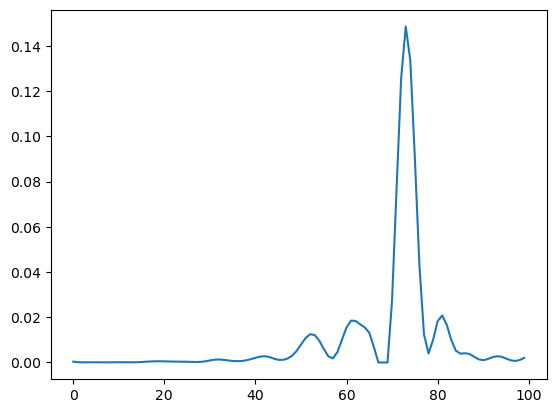

In [11]:
x = exo_model.optimization_.x
plt.plot(x)

In [500]:
np.savetxt('../data/autocor_errors/SRR1802184_errors.csv', errors, delimiter=',')

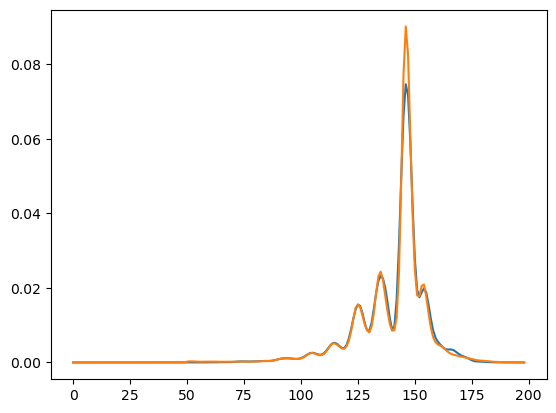

In [156]:
plt.plot(np.convolve(x, x))
plt.plot(hist)

NameError: name 'error' is not defined

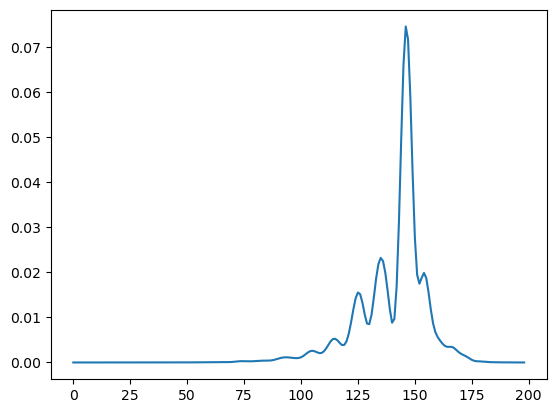

In [14]:
plt.plot(np.convolve(x, x))

In [666]:
class BamFileIterator:
    def __init__(self, pysam_path, chromosome, window_size=1000, step=200, start=0):
        self.al_file = pysam.AlignmentFile(pysam_path)
        self.chromosome = chromosome
        self.window_size = window_size
        self.step = step
        self.initial_start = start
        
        self.start = start
        self.stop = window_size
        self.chromo_len = dict(zip(self.al_file.references, self.al_file.lengths))[chromosome]

    def __del__(self):
        self.al_file.close()

    def __iter__(self):
        self.start = self.initial_start
        self.stop = self.start + self.window_size
        return self

    def __next__(self):
        records = list(self.al_file.fetch(self.chromosome, self.start, self.stop))
        paired_records = self._collect_paired_reads(records)
        items = {
            "start": torch.tensor(list(map(lambda x: x[0].reference_start, paired_records))).view(-1 ,1),
            "end": torch.tensor(list(map(lambda x: x[1].reference_end, paired_records))).view(-1, 1),
            "id": list(map(lambda x: x[0].qname, paired_records)),
        }
        if self.stop <= self.chromo_len:
            self.start += self.step
            self.stop = self.start + self.window_size
            return items
        else:
            return items
            raise StopIteration

    def _collect_paired_reads(self, records):
        read_pairs = defaultdict(dict)
        valid_pairs = []

        for read in records:
            name = read.query_name
            if read.is_read1:
                read_pairs[name]["R1"] = read
            elif read.is_read2:
                read_pairs[name]["R2"] = read

        # Отбираем только полные пары
        for name, pair in read_pairs.items():
            if "R1" in pair and "R2" in pair:
                valid_pairs.append((pair["R1"], pair["R2"]))
        return valid_pairs

In [667]:
class PysamRecordsDataset():
    def __init__(self, pysam_records):
        self.records = self._collect_paired_reads(pysam_records)
        self.chromosome = pysam_records[0].reference_name

    def __getitem__(self, idx: int):
        record = self.records[idx]
        items = {
            "start": record[0].reference_start,
            "end": record[1].reference_end,
            "id": record[0].qname,
            "chromo": record[0].reference_name,
        }
        return items

    def __len__(self):
        return len(self.records)

    def _collect_paired_reads(self, records):
        read_pairs = defaultdict(dict)
        valid_pairs = []

        for read in records:
            name = read.query_name
            if read.is_read1:
                read_pairs[name]["R1"] = read
            elif read.is_read2:
                read_pairs[name]["R2"] = read

        # Отбираем только полные пары
        for name, pair in read_pairs.items():
            if "R1" in pair and "R2" in pair:
                valid_pairs.append((pair["R1"], pair["R2"]))
        return valid_pairs

In [668]:
chrom_lengths = dict(zip(BAM_FILE.references, BAM_FILE.lengths))
chrom_lengths

{'NC_001133.9': 230218,
 'NC_001134.8': 813184,
 'NC_001135.5': 316620,
 'NC_001136.10': 1531933,
 'NC_001137.3': 576874,
 'NC_001138.5': 270161,
 'NC_001139.9': 1090940,
 'NC_001140.6': 562643,
 'NC_001141.2': 439888,
 'NC_001142.9': 745751,
 'NC_001143.9': 666816,
 'NC_001144.5': 1078177,
 'NC_001145.3': 924431,
 'NC_001146.8': 784333,
 'NC_001147.6': 1091291,
 'NC_001148.4': 948066,
 'NC_001224.1': 85779}

In [669]:
records1 = list(BAM_FILE.fetch("NC_001136.10", 20000 - 300, 21000 - 300))
records2 = list(BAM_FILE.fetch("NC_001136.10", 20000, 21000))
records3 = list(BAM_FILE.fetch("NC_001136.10", 20300, 21300))

In [670]:
records = list(BAM_FILE.fetch("NC_001136.10"))

In [671]:
a = iter(BamFileIterator(BAM_PATH, 'NC_001136.10', 1000))

In [675]:
next(a)

{'start': tensor([[ 583],
         [ 625],
         [ 625],
         [ 625],
         [ 627],
         [ 628],
         [ 628],
         [ 628],
         [ 628],
         [ 628],
         [ 628],
         [ 628],
         [ 628],
         [ 630],
         [ 649],
         [ 652],
         [ 652],
         [ 652],
         [ 652],
         [ 656],
         [ 656],
         [ 656],
         [ 658],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 663],
         [ 722],
         [ 724],
         [ 728],
         [ 728],
         [ 728],
         [ 728],
         [ 736],
         [ 745],
         [ 809],
         [ 819],
         [ 819],
         [ 819],
         [ 819],
         [ 819],
         [ 827],
         [ 828],
         [ 840],
         [ 847],
     

In [560]:
datasets1 = PysamRecordsDataset(records1)
datasets2 = PysamRecordsDataset(records2)
datasets3 = PysamRecordsDataset(records3)

In [561]:
loader1 = DataLoader(datasets1, 3000, False)
loader2 = DataLoader(datasets2, 3000, False)
loader3 = DataLoader(datasets3, 3000, False)

In [636]:
templates1 = next(iter(BamFileIterator(BAM_PATH, "NC_001136.10", start=20000, window_size=3000)))
templates2 = next(iter(BamFileIterator(BAM_PATH, "NC_001136.10", start=20200, window_size=3000)))
templates3 = next(iter(BamFileIterator(BAM_PATH, "NC_001136.10", start=20400, window_size=3000)))

In [ ]:
mext()

In [637]:
errors = torch.tensor(exo_model.optimization_.x)

In [638]:
L1 = templates1["start"].reshape(-1, 1)
R1 = templates1["end"].reshape(-1, 1)

L2 = templates2["start"].reshape(-1, 1)
R2 = templates2["end"].reshape(-1, 1)

L3 = templates3["start"].reshape(-1, 1)
R3 = templates3["end"].reshape(-1, 1)

In [639]:
class EMModel:
    def __init__(
        self,
        starts,
        stops,
        errors,
        n_initial,
        max_iter=500,
        reg_coef=0,
        tol=0.0001,
        dyads=None,
        weights=None,
        device="cpu",
    ):
        self.device = device
        self.starts = self.__validate_cords(starts)
        self.stops = self.__validate_cords(stops)
        self.errors = errors.to(device)
        self.n_initial = n_initial
        self.max_iter = max_iter
        self.dyads = self.__validate_dyads(dyads)
        self.weights = self.__validate_weights(weights)
        self.reg_coef = reg_coef
        self.tol = tol
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.Hij = torch.eye(*self.probs_matrix.shape, device=device)
        self.grid_probs = self.__create_grid_probs()

    @staticmethod
    def reset(model):
        new_model = type(model)(
            model.starts,
            model.stops,
            model.errors,
            model.ndyads,
            model.max_iter,
            model.reg_coef,
            model.tol,
            None,
            None,
            model.device,
        )
        return new_model

    @property
    def nreads(self):
        return len(self.starts)

    @property
    def ndyads(self):
        return len(self.weights)

    def __validate_cords(self, cords):
        return cords.to(self.device)

    def __validate_dyads(self, dyads=None):
        if dyads is None:
            dyads = (
                torch.linspace(
                    self.starts.min(),
                    self.stops.max(),
                    self.n_initial,
                    device=self.device,
                )
                .int()
                .reshape(-1, 1)
            )
        return dyads

    def __validate_weights(self, weights=None):
        if weights is None:
            weights = torch.rand(
                self.n_initial, dtype=float, device=self.device
            ).reshape(-1, 1)
            weights /= weights.sum()
        return weights

    def __create_probs_matrix(self, dyads):
        left_ones = (
            torch.ones((self.nreads, len(dyads)), dtype=float, device=self.device)
            * self.starts
        ).T
        right_ones = (
            torch.ones((self.nreads, len(dyads)), dtype=float, device=self.device)
            * self.stops
        ).T
        L_index = self.__insert_probs_to_matrix(dyads - left_ones, self.errors)
        R_index = self.__insert_probs_to_matrix(right_ones - dyads, self.errors)
        return (L_index * R_index).T

    def __create_grid_probs(self):
        potential_dyads = torch.arange(
            self.starts.min(), self.stops.max(), 1, device=self.device
        ).reshape(-1, 1)
        probs = torch.log(self.__create_probs_matrix(potential_dyads) + 1e-50)
        return probs

    def __insert_probs_to_matrix(self, idx_matrix, errors):
        valid_mask = (idx_matrix >= 0) & (idx_matrix < len(errors)).bool()
        idx_matrix[valid_mask] = errors[idx_matrix[valid_mask].int()]
        idx_matrix[~valid_mask] = 0
        return idx_matrix

    def e_step(self):
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.Hij = (self.probs_matrix * self.weights.T) / (
            self.probs_matrix @ self.weights
        )

    def m_step(self):
        self.dyads = (
            self.starts.min()
            + torch.argmax(self.grid_probs.T @ self.Hij, dim=0, keepdim=True).T
        )
        self.weights = self.Hij.sum(0, keepdim=True).T
        self.weights = self.weights / self.weights.sum() - self.reg_coef
        self.weights[self.weights < 0] = 0
        self.weights /= self.weights.sum()
        if (self.weights == 0).all() or self.weights.isnan().all():
            raise ValueError("all weights = 0. It seems reg_coef is too high")

    def run(self):
        cold_iter = 10
        prev = 0
        losses = []

        for i in range(self.max_iter):
            prev_hij = self.Hij

            self.e_step()
            self.m_step()

            if self.Hij.shape != prev_hij.shape:
                continue

            loss = (self.Hij - prev_hij).abs().sum().tolist()
            losses.append(loss)

            # if loss < self.tol:
            #     break

        # self.__delete_components()
        return losses

    def delete_components(self):
        keep_alive_mask = (self.weights > 0).bool().reshape(-1, 1)
        self.weights = self.weights[keep_alive_mask].reshape(-1, 1)
        self.weights /= self.weights.sum()
        self.dyads = self.dyads[keep_alive_mask].reshape(-1, 1)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)

    def to(self, device):
        """Move model to specified device"""
        self.device = device
        self.starts = self.starts.to(device)
        self.stops = self.stops.to(device)
        self.errors = self.errors.to(device)
        self.dyads = self.dyads.to(device)
        self.weights = self.weights.to(device)
        if self.probs_matrix is not None:
            self.probs_matrix = self.probs_matrix.to(device)
        if self.Hij is not None:
            self.Hij = self.Hij.to(device)

    def get_params(self):
        params = {
            "L": self.starts,
            "R": self.stops,
            "errors": self.errors,
            "n_initial": self.n_initial,
            "max_iter": self.max_iter,
            "reg_coef": self.reg_coef,
            "tol": self.tol,
            "dyads": self.dyads,
            "weights": self.weights,
            "device": self.device,
        }
        return params


class StochasticEMMOdel(EMModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def m_step(self):
        stochastic_res = self.__sample_multinomial_vectorized_torch()
        self.dyads = (
            self.starts.min()
            + torch.argmax(self.grid_probs.T @ stochastic_res, dim=0, keepdim=True).T
        )
        self.weights = (
            stochastic_res.sum(0, keepdim=True).T / self.ndyads - self.reg_coef
        )
        self.weights[self.weights < 0] = 0
        self.weights /= self.weights.sum()
        if (self.weights == 0).all():
            raise ValueError("all weights = 0. It seems reg_coef is too high")

    def __sample_multinomial_vectorized_torch(self):
        samples = torch.multinomial(self.Hij, num_samples=1).squeeze(-1)
        n_classes = self.Hij.shape[-1]
        stochastic_res = torch.nn.functional.one_hot(
            samples, num_classes=n_classes
        ).float()
        return stochastic_res.double()

    def run(self):
        cold_iter = 30
        smoothed_change = 0
        alpha = 0.3  # коэффициент сглаживания
        history = []
        convergence_count = 0

        for i in range(self.max_iter):
            prev_hij = self.Hij

            if i < cold_iter:
                super().e_step()
                super().m_step()

            else:
                self.e_step()
                self.m_step()
                self.delete_components()

            if self.Hij.shape != prev_hij.shape:
                continue

            # Вычисляем изменение
            current_change = (self.Hij - prev_hij).abs().mean().item()

            # Экспоненциальное сглаживание
            smoothed_change = alpha * current_change + (1 - alpha) * smoothed_change
            history.append(smoothed_change)

            # Условия сходимости
            if i > cold_iter and smoothed_change < self.tol:
                # Дополнительная проверка: стабильность в течение нескольких итераций
                convergence_count += 1

                if convergence_count >= 5:
                    break
            else:
                convergence_count = 0

        return history

In [640]:
model = StochasticEMMOdel(
    L1, R1, errors, 150, reg_coef=0.0009, max_iter=500, device="cuda:1"
)

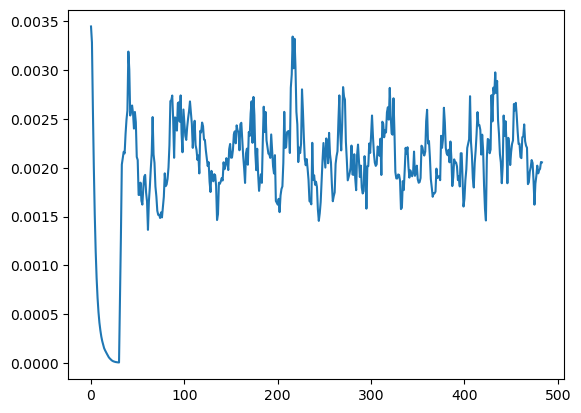

In [642]:
plt.plot(l)

In [643]:
import copy


def optimize_reg_coef(model, max_iter=30, max_successful_runs=5):
    best_model = copy.deepcopy(model)
    low, high = 0, 0.1
    best_nonzero = (best_model.weights > 0).sum().item()
    successful_runs = 0

    for i in range(max_iter):
        mid = (low + high) / 2

        new_model = copy.deepcopy(model)
        new_model.reg_coef = mid

        try:
            new_model.run()
            successful_runs += 1
            current_nonzero = (new_model.weights > 0).sum().item()

            print(f"Iter {i}: reg_coef={mid:.4f}, components={current_nonzero}")

            if current_nonzero > 0:
                if current_nonzero < best_nonzero:
                    best_model = copy.deepcopy(new_model)
                    best_nonzero = (best_model.weights > 0).sum().item()

                low = mid
            else:
                high = mid

            if successful_runs >= max_successful_runs:
                break

        except Exception as error:
            print(f"Error with reg_coef={mid:.4f}: {error}")
            high = mid

    return best_model

In [645]:
model1, model2, model3 = (
    StochasticEMMOdel(
        L1, R1, errors, 500, reg_coef=0.0009, max_iter=300, device="cuda:1"
    ),
    StochasticEMMOdel(
        L2, R2, errors, 500, reg_coef=0.0009, max_iter=300, device="cuda:1"
    ),
    StochasticEMMOdel(
        L3, R3, errors, 500, reg_coef=0.0009, max_iter=300, device="cuda:1"
    ),
)

In [646]:
# r1 = model1.run()
# r2 = model2.run()
# r3 = model3.run()

In [647]:
# plt.plot(r1)
# plt.plot(r2)
# plt.plot(r3)

In [648]:
m1 = optimize_reg_coef(model1)
m2 = optimize_reg_coef(model2)
m3 = optimize_reg_coef(model3)

Error with reg_coef=0.0500: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0250: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0125: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0063: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0031: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0016: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0008: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0004: all weights = 0. It seems reg_coef is too high
Iter 8: reg_coef=0.0002, components=156
Error with reg_coef=0.0003: all weights = 0. It seems reg_coef is too high
Iter 10: reg_coef=0.0002, components=153
Iter 11: reg_coef=0.0003, components=152
Error with reg_coef=0.0003: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0003: all weights = 0. It seems reg_coef is too high
Error with reg_coef=0.0003: all weights = 0. It seems

In [649]:
# model1.to('cpu')
# model2.to('cpu')
# model3.to('cpu')

In [650]:
calculate_bic(model)

tensor(nan, device='cuda:1', dtype=torch.float64)

In [651]:
def make_df(model):
    if model.device != "cpu":
        model.to("cpu")
    df = pd.DataFrame({"start": model.starts.flatten(), "stop": model.stops.flatten()})
    df["dyads"] = model.dyads[model.Hij.argmax(1)]
    df["template|dyad"] = model.Hij.max(1)[0]
    return df


def make_occupancy(starts, stops):
    min_value = starts.min()
    max_value = stops.max()
    x = np.arange(min_value, max_value + 1)
    occ = np.zeros_like(x)
    for start, stop in zip(starts, stops):
        occ[start - min_value : stop - min_value + 1] += 1
    return x, occ


def make_template_occupancy(dyads, template):
    min_value = dyads.min()
    max_value = dyads.max()
    x = np.arange(min_value - len(template), max_value + len(template), dtype=float)
    occ = np.zeros_like(x)
    for dyad in dyads:
        start_pos = dyad - len(template) // 2 - min_value + len(template)
        occ[start_pos : start_pos + len(template)] += template
    return (
        x[len(template) // 2 : -len(template) // 2],
        occ[len(template) // 2 : -len(template) // 2],
    )

In [652]:
# rmsd1 = grid_reg_coef(model1, np.linspace(0.0001, 1, 10))

# m2 = grid_search(model1, np.linspace(0.0001, 1, 10))

# m3 = grid_search(model1, np.linspace(0.0001, 1, 10))

In [653]:
df1, df2, df3 = make_df(m1), make_df(m2), make_df(m3)
df1["label"] = 1
df2["label"] = 2
df3["label"] = 3

df = pd.concat([df1, df2, df3])

In [654]:
import os
from pathlib import Path

os.path.join("", "as")

'as'

In [655]:
filename

PosixPath('/home/d_ryabov/NucDPosIT/notebooks')

In [656]:
df1

,start,stop,dyads,template|dyad,label
0,19957,20103,20038,1.000000,1
1,19960,20094,20038,1.000000,1
2,19963,20026,19963,1.000000,1
3,19965,20112,20038,1.000000,1
4,19965,20102,20038,1.000000,1
...,...,...,...,...,...
1363,22860,22996,22921,0.992382,1
1364,22864,22996,22921,0.992892,1
1365,22877,22993,22921,0.929792,1
1366,22877,22993,22921,0.929792,1


In [657]:
g = df1.groupby("dyads", as_index=False).size()
g["chr"] = "NC_001136.10"
g["stop"] = g["dyads"] + 1
g[["chr", "dyads", "stop", "size"]]

,chr,dyads,stop,size
0,NC_001136.10,19963,19964,1
1,NC_001136.10,20038,20039,9
2,NC_001136.10,20073,20074,4
3,NC_001136.10,20120,20121,4
4,NC_001136.10,20133,20134,3
...,...,...,...,...
147,NC_001136.10,22865,22866,4
148,NC_001136.10,22880,22881,6
149,NC_001136.10,22898,22899,6
150,NC_001136.10,22921,22922,6


In [658]:
x1, occ1 = make_occupancy(L1.numpy().flatten(), R1.numpy().flatten())
x2, occ2 = make_occupancy(L2.numpy().flatten(), R2.numpy().flatten())
x3, occ3 = make_occupancy(L3.numpy().flatten(), R3.numpy().flatten())

template_x1, templates_occ1 = make_template_occupancy(
    df1.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x2, templates_occ2 = make_template_occupancy(
    df2.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x3, templates_occ3 = make_template_occupancy(
    df3.dyads.to_numpy(), ExoNucTemplate().nuc_template
)

c1 = Counter(df1.dyads.values)
bars1 = [c1[i] for i in x1]

c2 = Counter(df2.dyads.values)
bars2 = [c2[i] for i in x2]

c3 = Counter(df3.dyads.values)
bars3 = [c3[i] for i in x3]

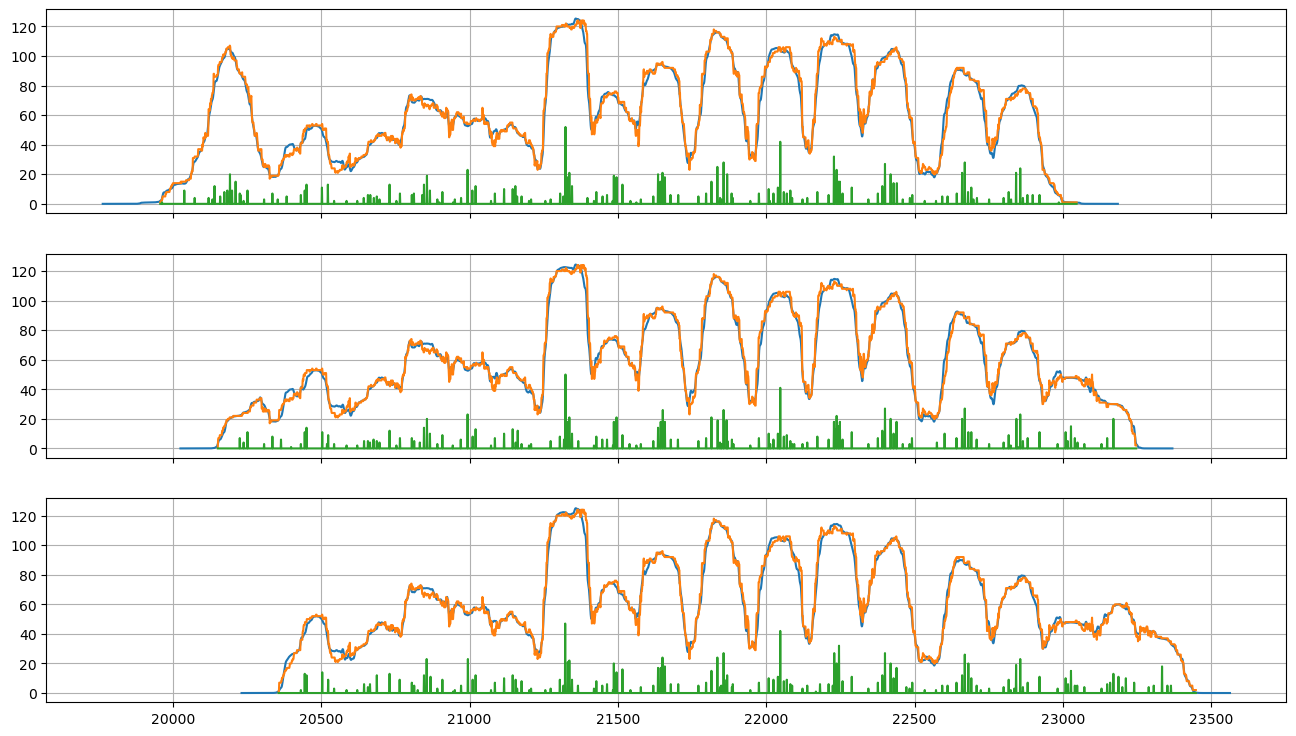

In [659]:
fig, axs = plt.subplots(3, 1, figsize=(16, 9), sharex=True, sharey=True)


axs[0].plot(template_x1, templates_occ1)
axs[0].plot(x1, occ1)
axs[0].plot(x1, bars1)
axs[0].grid()

axs[1].plot(template_x2, templates_occ2)
axs[1].plot(x2, occ2)
axs[1].plot(x2, bars2)
axs[1].grid()

axs[2].plot(template_x3, templates_occ3)
axs[2].plot(x3, occ3)
axs[2].plot(x3, bars3)
axs[2].grid()

# fig.savefig("../data/figs/fit_exo_figs/tmp/convergence.png")

(20000.0, 22500.0)

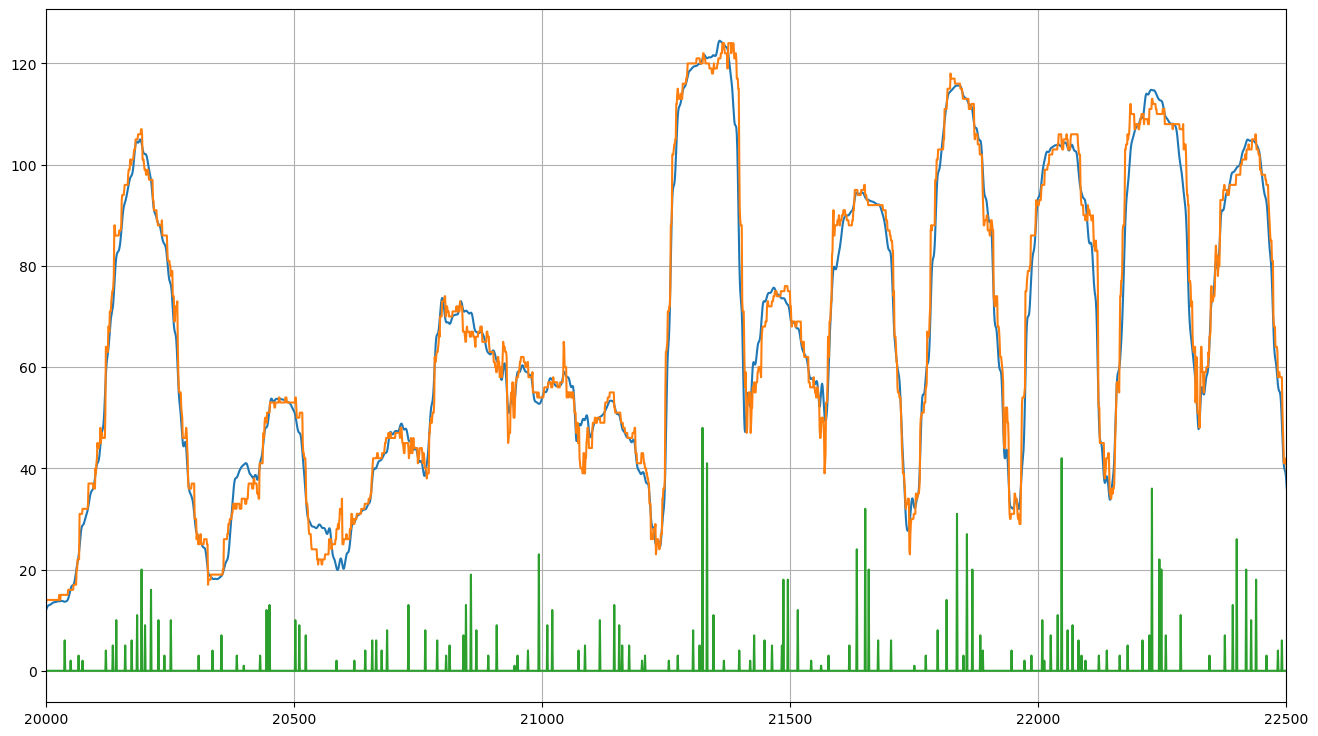

In [635]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)


ax.plot(template_x1, templates_occ1)
ax.plot(x1, occ1)
ax.plot(x1, bars1)
ax.grid()

plt.xlim(20000, 22500)

In [2360]:
from scipy.stats import wasserstein_distance

wasserstein_distance(
    model1.dyads.numpy().flatten(),
    model2.dyads.numpy().flatten(),
    model1.weights.numpy().flatten(),
    model2.dyads.numpy().flatten(),
)

np.float64(189.60623620294223)

In [5346]:
df = pd.DataFrame({"start": L.flatten(), "stop": R.flatten()})
df["dyads"] = model.dyads[model.Hij.argmax(1)]
df["center"] = (df.start + df.stop) // 2
df["dyad_prob"] = model.weights[model.Hij.argmax(1)]

In [5403]:
q = np.quantile(df.dyad_prob, 0)

In [5404]:
df_filtered = df.query("dyad_prob > @q")

In [5405]:
reads_dyads = df_filtered.dyads.to_numpy()

In [5406]:
reads_dyads

array([10039, 10039, 10039, ..., 14960, 14944, 14960], shape=(2390,))

In [5407]:
x, occ = make_occupancy(L.numpy().flatten(), R.numpy().flatten())
template_x, templates_occ = make_template_occupancy(
    reads_dyads, exo_template.nuc_template
)

c = Counter(df_filtered.dyads.values)
bars = [c[i] for i in x]

(10000.0, 12000.0)

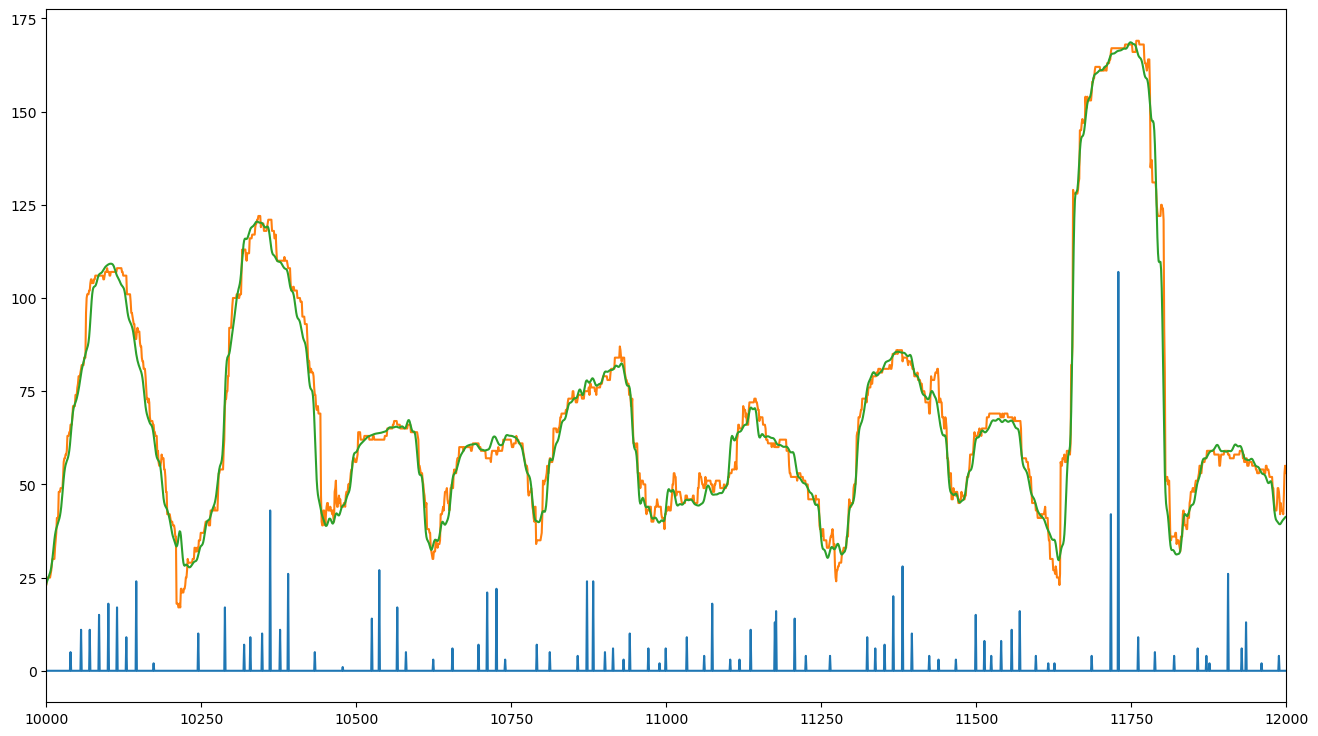

In [5408]:
plt.figure(figsize=(16, 9))
_ = plt.plot(x, bars)
plt.plot(x, occ)
plt.plot(template_x, templates_occ)


plt.xlim(10000, 12000)

In [5391]:
df_filtered

,start,stop,dyads,center,dyad_prob
0,9954,10123,10039,10038,0.001990
1,9958,10101,10039,10029,0.001990
2,9958,10098,10039,10028,0.001990
3,9964,10091,10039,10027,0.001990
4,9967,10073,10039,10020,0.001990
...,...,...,...,...,...
2386,14868,15037,14944,14952,0.000871
2387,14872,15018,14944,14945,0.000871
2388,14886,15035,14960,14960,0.000567
2389,14902,15018,14944,14960,0.000871
